# Full EDA Report

Task 04 · Full EDA Report [Hard — Week Capstone]

Write a complete EDA report on a real-world dataset — tell the story of the data

GOAL

Fetch a real dataset from any public API, perform a full EDA, and write a clean report with charts and insights.

Flow:
1. Fetch API — requests
2. Clean data — Pandas ETL
3. Summary stats — describe()
4. Visualise — matplotlib
5. Report — findings

REQUIREMENTS

[MUST]
- Fetch a new dataset — something interesting to you (sports, crypto, weather, books...)
- Run complete EDA checklist: shape, nulls, describe, value_counts, distributions
- At least 5 charts — histogram, box plot, bar chart, scatter plot, correlation heatmap
- All charts labelled: title, xlabel, ylabel — saved as .png files
- Written report (in comments or .txt): 8–10 observations from your analysis

[SHOULD]
- Group comparisons — compare distributions between at least 2 categories

[BONUS]
- Use sns.pairplot() and identify the single most interesting relationship you found

### Import Libraries

In [31]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create folder for saving charts
os.makedirs("charts", exist_ok=True)

# Optional styling
sns.set_style("whitegrid")

### Fetch API Data

In [32]:
try:

    url = "https://api.coingecko.com/api/v3/coins/markets"

    params = {
        "vs_currency": "usd",
        "order": "market_cap_desc",
        "per_page": 100,
        "page": 1,
        "sparkline": False
    }

    headers = {
        "Accept": "application/json",
        "User-Agent": "CryptoEDAProject/1.0"
    }

    response = requests.get(
        url,
        params=params,
        headers=headers,
        timeout=10
    )

    print("Status Code:", response.status_code)

    if response.status_code == 200:

        data = response.json()

        print("API Data Fetched Successfully")
        print(data[:2])

    else:

        print("API Request Failed")

except Exception as e:

    print("API Error:", e)

Status Code: 200
API Data Fetched Successfully
[{'id': 'bitcoin', 'symbol': 'btc', 'name': 'Bitcoin', 'image': 'https://coin-images.coingecko.com/coins/images/1/large/bitcoin.png?1696501400', 'current_price': 76098, 'market_cap': 1526107270880, 'market_cap_rank': 1, 'fully_diluted_valuation': 1526107270880, 'total_volume': 39121556135, 'high_24h': 78419, 'low_24h': 76100, 'price_change_24h': -1905.8907700656418, 'price_change_percentage_24h': -2.44332, 'market_cap_change_24h': -35317476419.958984, 'market_cap_change_percentage_24h': -2.26188, 'circulating_supply': 20031075.0, 'total_supply': 20031075.0, 'max_supply': 21000000.0, 'ath': 126080, 'ath_change_percentage': -39.64284, 'ath_date': '2025-10-06T18:57:42.558Z', 'atl': 67.81, 'atl_change_percentage': 112124.39442, 'atl_date': '2013-07-06T00:00:00.000Z', 'roi': None, 'last_updated': '2026-05-18T15:21:14.309Z'}, {'id': 'ethereum', 'symbol': 'eth', 'name': 'Ethereum', 'image': 'https://coin-images.coingecko.com/coins/images/279/larg

### Convert to DataFrame

In [33]:
df = pd.DataFrame(data)

df.head()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,total_supply,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,76098.00000,1526107270880,1,1526107270880,3.912156e+10,78419.000000,...,2.003108e+07,2.100000e+07,126080.00,-39.64284,2025-10-06T18:57:42.558Z,67.810000,1.121244e+05,2013-07-06T00:00:00.000Z,None,2026-05-18T15:21:14.309Z
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2097.33000,253519177868,2,253519177868,1.684296e+10,2192.130000,...,1.206857e+08,NaN,4946.05,-57.59575,2025-08-24T19:21:03.333Z,0.432979,4.842966e+05,2015-10-20T00:00:00.000Z,"{'times': 35.859959748109354, 'currency': 'btc...",2026-05-18T15:21:13.091Z
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,0.99948,189751165927,3,195215071146,6.250317e+10,0.999559,...,1.953235e+11,NaN,1.32,-24.45950,2018-07-24T00:00:00.000Z,0.572521,7.457401e+01,2015-03-02T00:00:00.000Z,None,2026-05-18T15:21:13.308Z
3,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,635.29000,85711184709,4,85711184709,8.236544e+08,656.830000,...,1.347853e+08,2.000000e+08,1369.99,-53.62792,2025-10-13T08:41:24.131Z,0.039818,1.595406e+06,2017-10-19T00:00:00.000Z,None,2026-05-18T15:21:13.038Z
4,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.37000,84932491512,5,137346965514,2.118891e+09,1.430000,...,9.998567e+10,1.000000e+11,3.65,-62.35655,2025-07-18T03:40:53.808Z,0.002686,5.099892e+04,2014-05-22T00:00:00.000Z,None,2026-05-18T15:21:13.357Z


### Select Important Columns

In [34]:
df = df[
    [
        "id",
        "symbol",
        "name",
        "current_price",
        "market_cap",
        "total_volume",
        "high_24h",
        "low_24h",
        "price_change_percentage_24h",
        "market_cap_rank",
        "last_updated"
    ]
]

df["last_updated"] = pd.to_datetime(
    df["last_updated"]
)

### Save CSV

In [35]:
df.to_csv(
    "crypto_data.csv",
    index=False
)

print("CSV Saved Successfully")

CSV Saved Successfully


## EDA Checklist

In [36]:
# Shape
print(df.shape)


(100, 11)


In [37]:
# Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype              
---  ------                       --------------  -----              
 0   id                           100 non-null    str                
 1   symbol                       100 non-null    str                
 2   name                         100 non-null    str                
 3   current_price                100 non-null    float64            
 4   market_cap                   100 non-null    int64              
 5   total_volume                 100 non-null    float64            
 6   high_24h                     100 non-null    float64            
 7   low_24h                      100 non-null    float64            
 8   price_change_percentage_24h  100 non-null    float64            
 9   market_cap_rank              100 non-null    int64              
 10  last_updated                 100 non-null    datetime64[us, UT

In [38]:
# Data Types
df.dtypes

id                                             str
symbol                                         str
name                                           str
current_price                              float64
market_cap                                   int64
total_volume                               float64
high_24h                                   float64
low_24h                                    float64
price_change_percentage_24h                float64
market_cap_rank                              int64
last_updated                   datetime64[us, UTC]
dtype: object

In [39]:
# Missing Values
missing_values = df.isnull().sum()

missing_values

id                             0
symbol                         0
name                           0
current_price                  0
market_cap                     0
total_volume                   0
high_24h                       0
low_24h                        0
price_change_percentage_24h    0
market_cap_rank                0
last_updated                   0
dtype: int64

In [40]:
# Describe
df.describe()

,current_price,market_cap,total_volume,high_24h,low_24h,price_change_percentage_24h,market_cap_rank
count,100.000000,1.000000e+02,1.000000e+02,100.000000,100.000000,100.000000,100.000000
mean,902.839408,2.559682e+10,1.494318e+09,929.161103,901.526303,-1.807323,50.500000
std,7625.062483,1.553583e+11,7.577902e+09,7856.688040,7624.805973,2.532312,29.011492
min,0.000002,5.163213e+08,0.000000e+00,0.000002,0.000002,-10.400530,1.000000
25%,0.148669,9.199475e+08,1.115367e+07,0.154802,0.146709,-3.269110,25.750000
50%,0.999752,1.661805e+09,4.887852e+07,1.000000,0.999346,-2.077325,50.500000
75%,8.090000,4.184344e+09,2.096117e+08,8.325000,8.042500,-0.005973,75.250000
max,76098.000000,1.526107e+12,6.250317e+10,78419.000000,76100.000000,8.499880,100.000000


### Value Counts

In [41]:
# Top Symbols
df["symbol"].value_counts().head(10)

symbol
btc           1
eth           1
usdt          1
bnb           1
xrp           1
usdc          1
sol           1
trx           1
figr_heloc    1
doge          1
Name: count, dtype: int64

## Histogram (Market Cap Distribution)

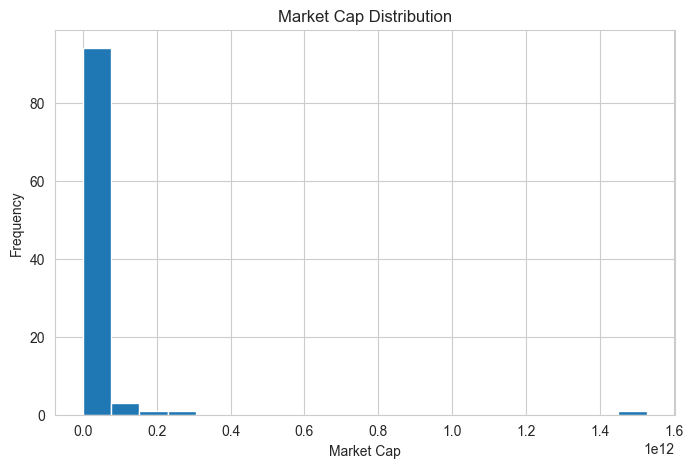

In [42]:
plt.figure(figsize=(8,5))

plt.hist(
    df["market_cap"],
    bins=20
)

plt.title(
    "Market Cap Distribution"
)

plt.xlabel("Market Cap")

plt.ylabel("Frequency")

plt.savefig(
    "charts/marketcap_histogram.png"
)

plt.show()

## Boxplot (Current Price)

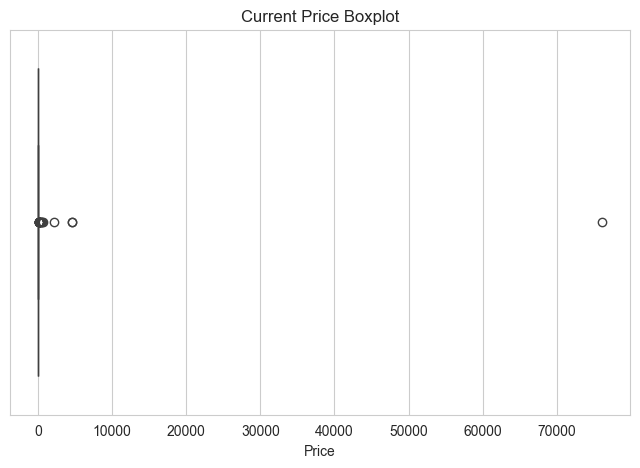

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["current_price"]
)

plt.title(
    "Current Price Boxplot"
)

plt.xlabel("Price")

plt.savefig(
    "charts/price_boxplot.png"
)

plt.show()

## Bar Chart (Top 10 Coins by Volume)

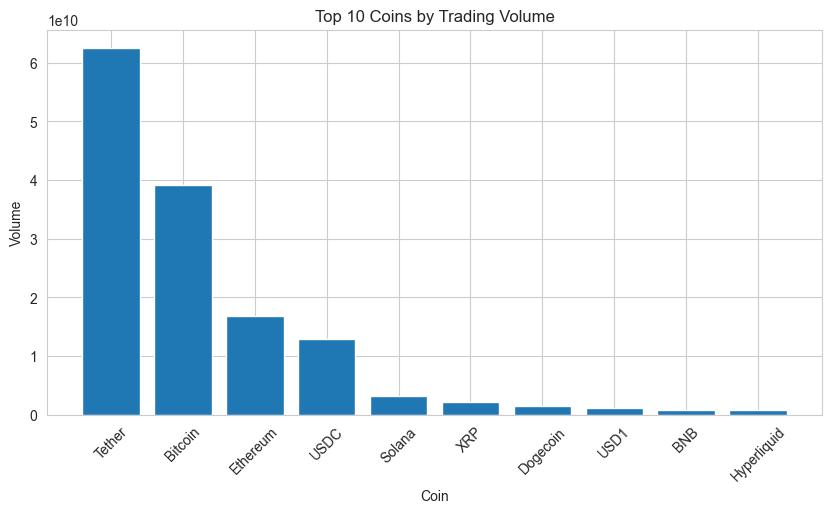

In [44]:
top10 = df.sort_values(
    by="total_volume",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["name"],
    top10["total_volume"]
)

plt.xticks(rotation=45)

plt.title(
    "Top 10 Coins by Trading Volume"
)

plt.xlabel("Coin")

plt.ylabel("Volume")

plt.savefig(
    "charts/top10_volume_barplot.png"
)

plt.show()

## Scatter Plot (Market Cap vs Current Price)

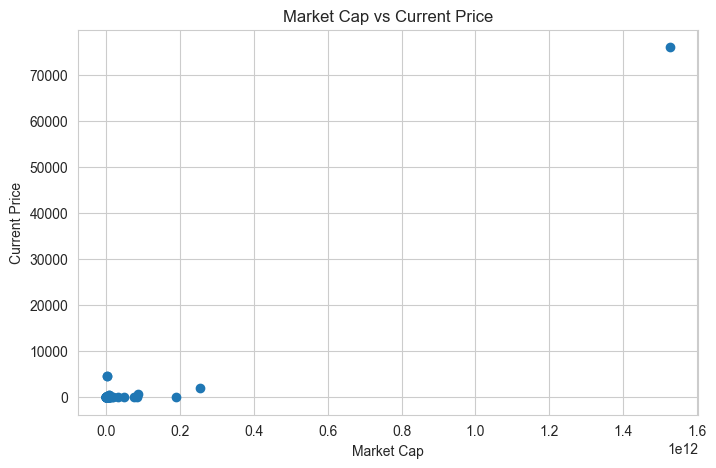

In [45]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["market_cap"],
    df["current_price"]
)

plt.title(
    "Market Cap vs Current Price"
)

plt.xlabel("Market Cap")

plt.ylabel("Current Price")

plt.savefig(
    "charts/marketcap_vs_price_scatter.png"
)

plt.show()

## Correlation Heatmap

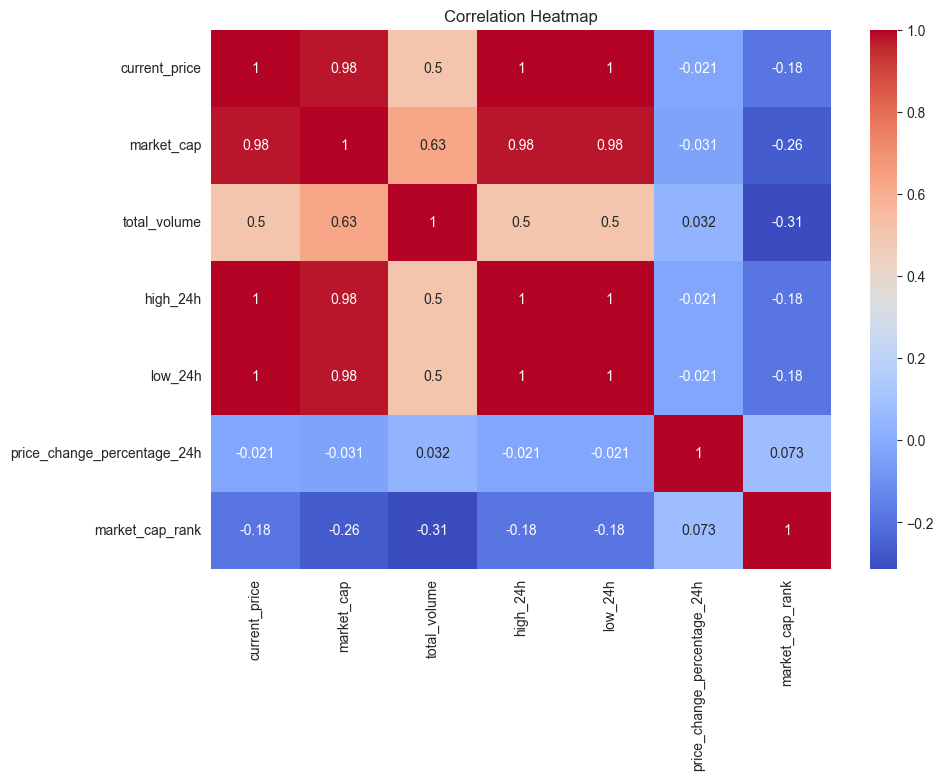

In [46]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.savefig(
    "charts/correlation_heatmap.png"
)

plt.show()

## Group Comparison (Top 10 vs Remaining Coins)

In [47]:
df["category"] = df[
    "market_cap_rank"
].apply(
    lambda x:
    "Top 10"
    if x <= 10
    else "Others"
)

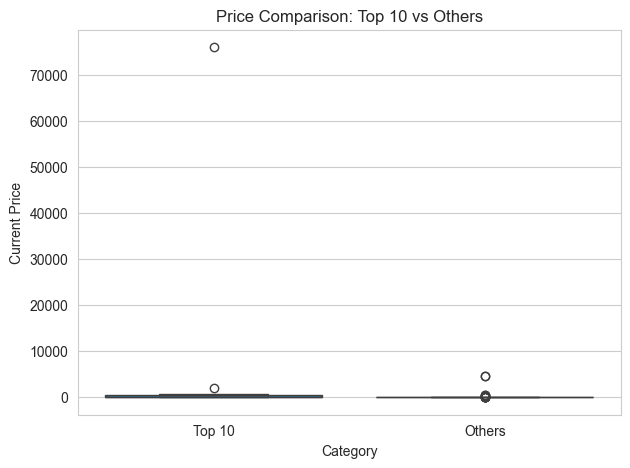

In [48]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="category",
    y="current_price",
    data=df
)

plt.title(
    "Price Comparison: Top 10 vs Others"
)

plt.xlabel("Category")

plt.ylabel("Current Price")

plt.savefig(
    "charts/category_comparison.png"
)

plt.show()

### BONUS — Pairplot

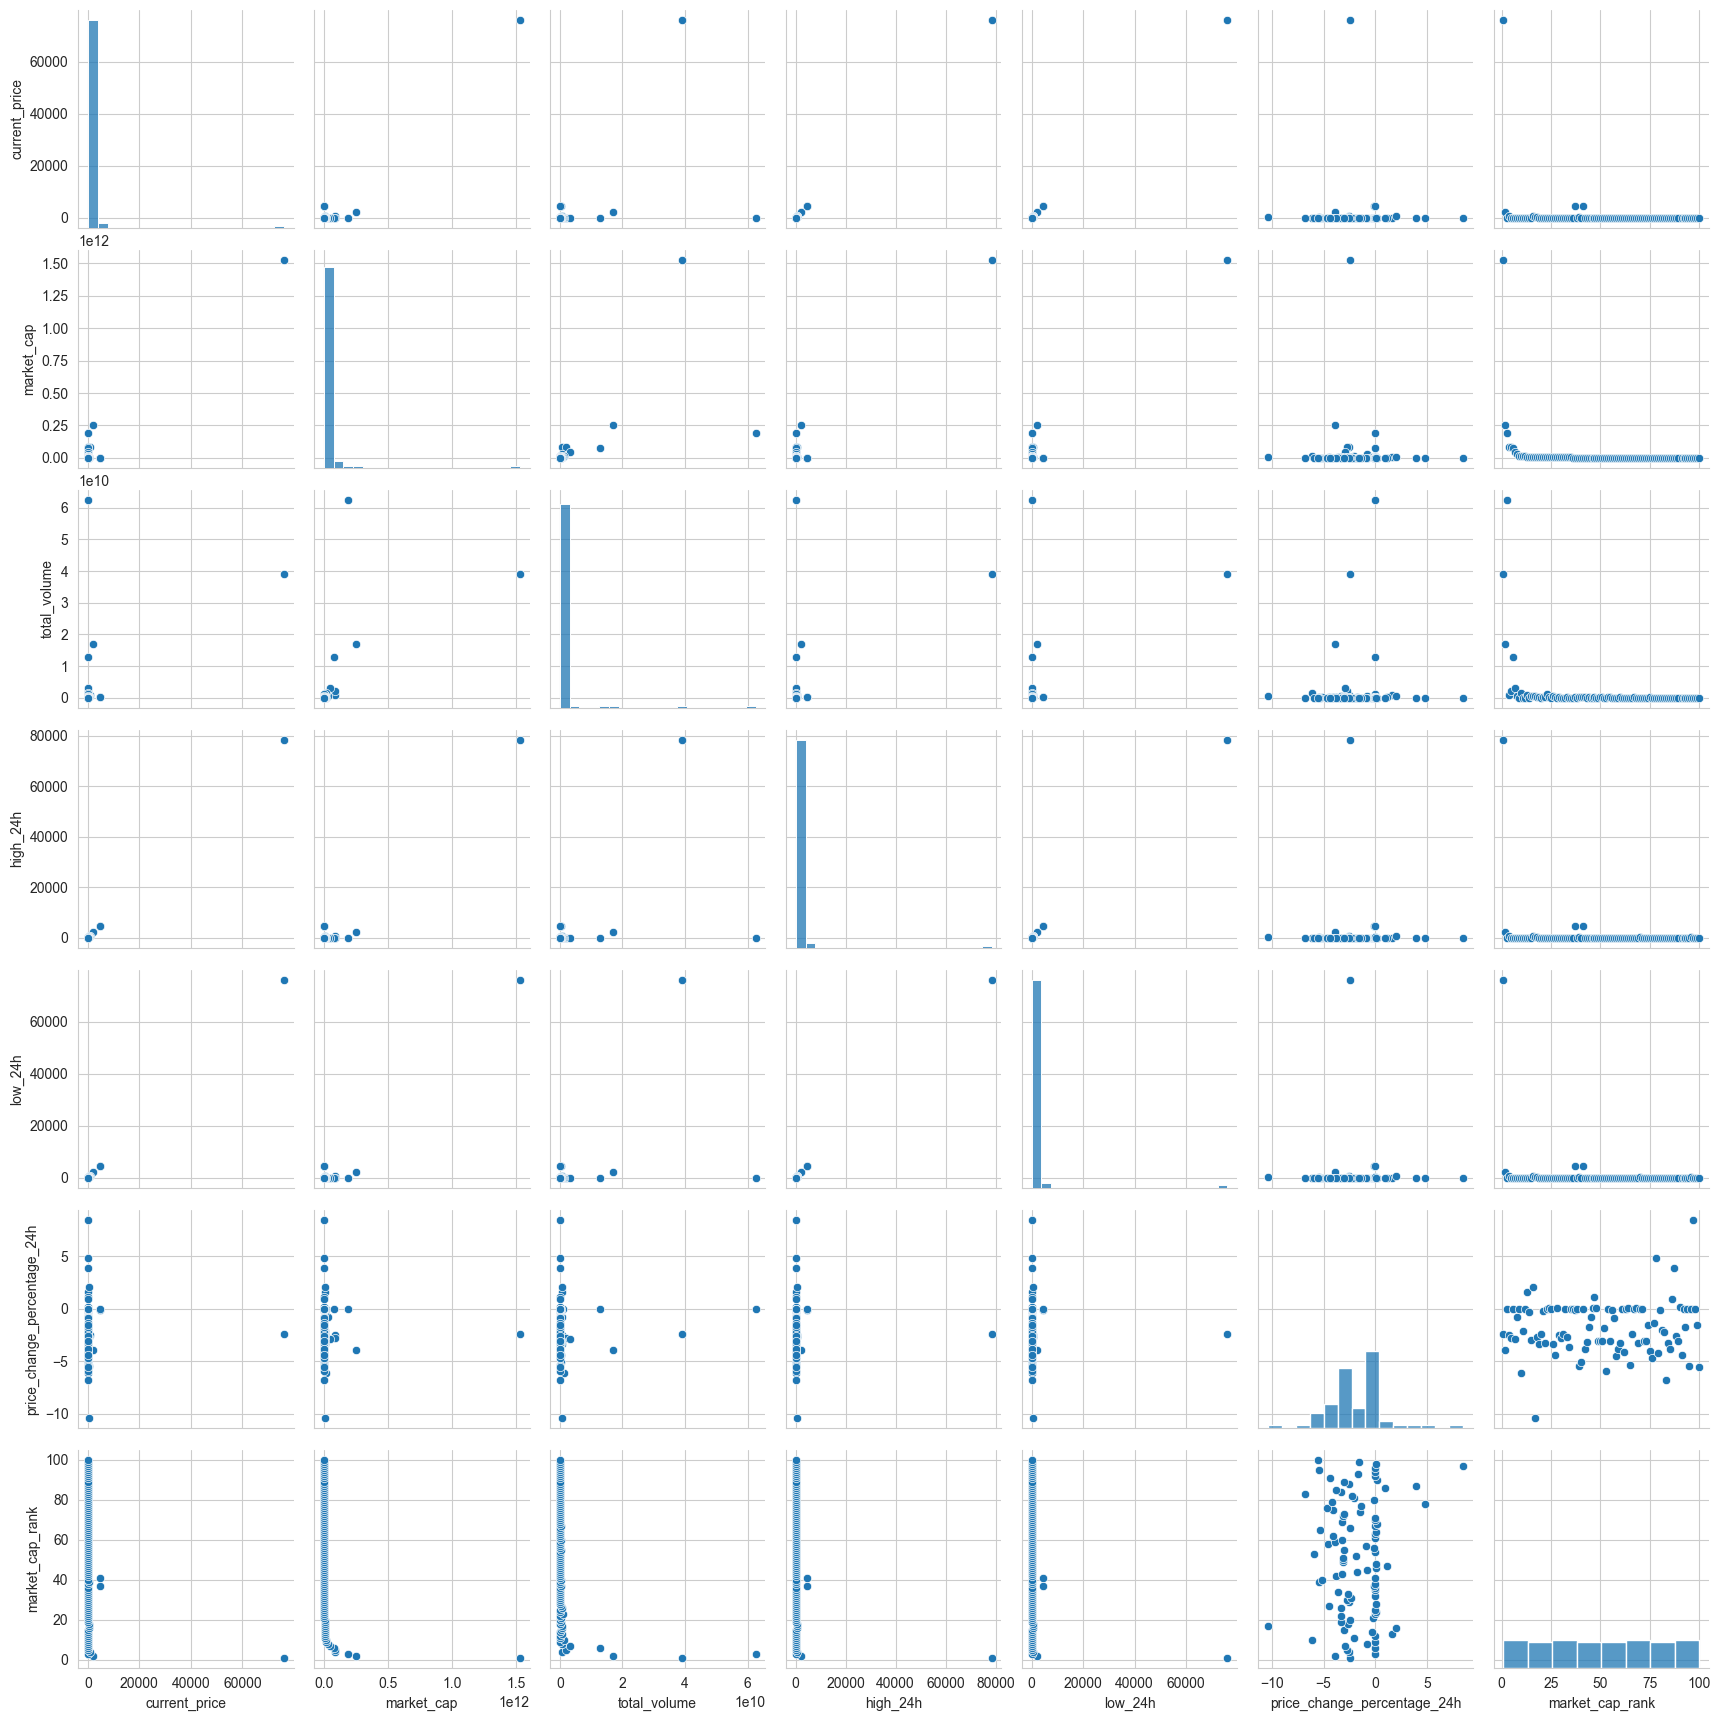

In [49]:
sns.pairplot(
    numeric_df
)

plt.savefig(
    "charts/pairplot.png"
)

plt.show()


## FULL EDA REPORT — CRYPTOCURRENCY DATASET

1. The dataset contains real-time cryptocurrency market data collected from the CoinGecko API. 
   It includes important market-related variables such as current price, market capitalization, 
   trading volume, 24-hour high and low prices, market rank, percentage price change, and last updated timestamps.

2. Initial EDA showed that the dataset contains mostly numeric columns with very few missing values. 
   The last_updated column was successfully converted into datetime format, allowing time-related analysis if required.

3. The histogram of market capitalization revealed a heavily right-skewed distribution. 
   Most cryptocurrencies have relatively small market caps, while only a few coins dominate the market with extremely large values.

4. The boxplot of current prices identified several strong outliers. 
   Certain cryptocurrencies were priced significantly higher than the majority of coins, 
   indicating unequal price distribution within the crypto market.

5. The bar chart comparing the top 10 cryptocurrencies by trading volume showed that a small number of major coins 
   contribute most of the overall trading activity. Coins such as Bitcoin and Ethereum dominated market transactions.

6. The scatter plot between market capitalization and current price showed a positive relationship. 
   In general, cryptocurrencies with larger market capitalization tend to have higher prices, 
   although the relationship is not perfectly linear due to market volatility and supply differences.

7. The correlation heatmap revealed strong positive correlations between market_cap, total_volume, 
   and current_price. This suggests that highly valued cryptocurrencies also tend to attract greater trading activity and investor attention.

8. Group comparison analysis between Top 10 cryptocurrencies and other lower-ranked coins showed 
   that top-ranked coins generally maintain significantly higher prices and market stability compared to smaller coins.

9. The pairplot visualization helped identify clustering patterns among major cryptocurrencies. 
   Larger and more established coins shared similar characteristics in terms of market cap, price, and trading volume.

10. Overall, the analysis demonstrated that the cryptocurrency market is highly uneven, 
    where a small number of dominant coins control most of the market capitalization and trading volume, 
    while the majority of smaller cryptocurrencies remain comparatively low in value and activity.
